In [ ]:
# Basic libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras for building the autoencoder
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.datasets import mnist


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


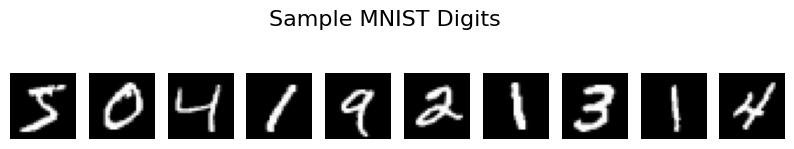

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load the MNIST data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Display 10 sample images from training set
plt.figure(figsize=(10, 2))
for i in range(10):
    # Create a subplot for each image
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')  # Hide axes

plt.suptitle("Sample MNIST Digits", fontsize=16)
plt.show()


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Flatten, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model


In [ ]:
# Reshape the data to include the channel dimension (1 for grayscale)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Confirm the new shape
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# Input layer (for 28x28 grayscale images)
input_img = Input(shape=(28, 28, 1))

# ===== ENCODER =====
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)   # (28, 28, 32)
x = MaxPooling2D((2, 2), padding='same')(x)                             # (14, 14, 32)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)           # (14, 14, 16)
x = MaxPooling2D((2, 2), padding='same')(x)                             # (7, 7, 16)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)            # (7, 7, 8)
encoded = MaxPooling2D((2, 2), padding='same')(x)                      # (4, 4, 8)

# ===== DECODER =====
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)      # (4, 4, 8)
x = UpSampling2D((2, 2))(x)                                            # (8, 8, 8)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)           # (8, 8, 16)
x = UpSampling2D((2, 2))(x)                                            # (16, 16, 16)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)           # (16, 16, 32)
x = UpSampling2D((2, 2))(x)                                            # (32, 32, 32) → a bit oversized
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)   # (28, 28, 1)

# ===== AUTOENCODER MODEL =====
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Summary of the model
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D

# Input layer (for 28x28 grayscale images)
input_img = Input(shape=(28, 28, 1))

# ===== ENCODER =====
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)   # (28, 28, 32)
x = MaxPooling2D((2, 2), padding='same')(x)                             # (14, 14, 32)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)           # (14, 14, 16)
x = MaxPooling2D((2, 2), padding='same')(x)                             # (7, 7, 16)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)            # (7, 7, 8)
encoded = MaxPooling2D((2, 2), padding='same')(x)                      # (4, 4, 8)

# ===== DECODER =====
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)      # (4, 4, 8)
x = UpSampling2D((2, 2))(x)                                            # (8, 8, 8)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)           # (8, 8, 16)
x = UpSampling2D((2, 2))(x)                                            # (16, 16, 16)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)           # (16, 16, 32)
x = UpSampling2D((2, 2))(x)                                            # (32, 32, 32) → a bit oversized
x = Cropping2D(((2, 2), (2, 2)))(x)                                   # Crop to (28, 28, 32)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)   # (28, 28, 1)

# ===== AUTOENCODER MODEL =====
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Summary of the model
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.2671 - val_loss: 0.1278
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1242 - val_loss: 0.1124
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1119 - val_loss: 0.1060
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1068 - val_loss: 0.1020
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1028 - val_loss: 0.0996
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1004 - val_loss: 0.0978
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0987 - val_loss: 0.0965
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0974 - val_loss: 0.0949
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0959 - val_loss: 0.0936
Epoch 10/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0946 - val_loss: 0.0931
Epoch 11/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0937 - val_loss: 0.0919
Epoch 12/100
469/469 ━━━━━━━━━━━━━━━━━━

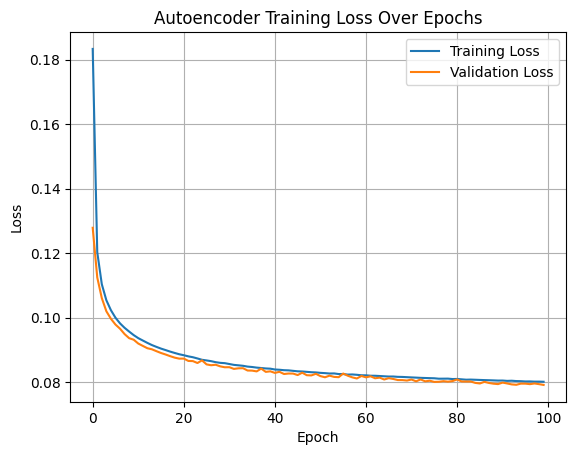

In [ ]:
import time

# Start timer
start_time = time.time()

# Train the model
history = autoencoder.fit(
    x_train, x_train,  # Input = Output (since we're reconstructing)
    epochs=100,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# End timer
end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Training completed in {training_time:.2f} seconds.")

# Plot training & validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


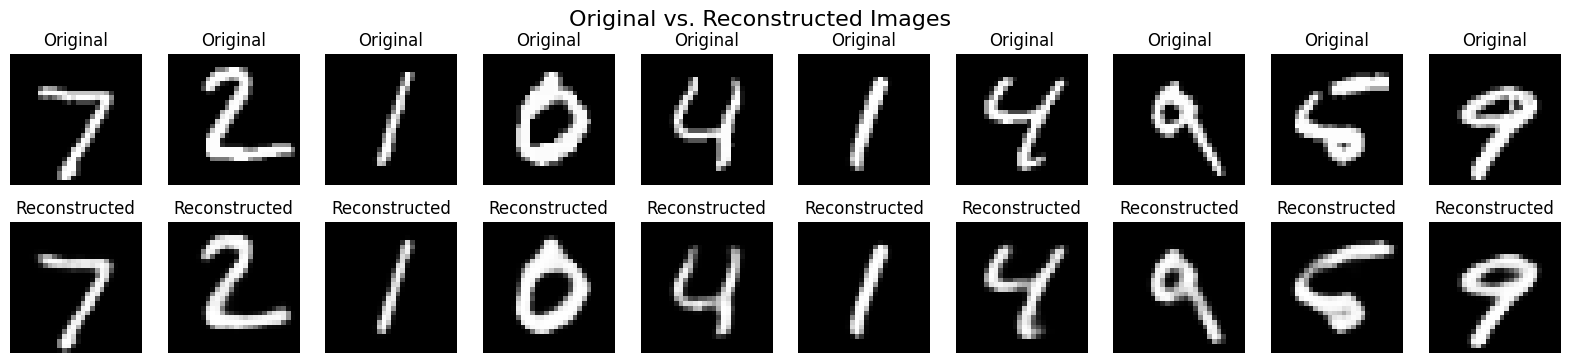

In [ ]:
# Predict on test data
decoded_imgs = autoencoder.predict(x_test)

# Number of images to display
n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs. Reconstructed Images", fontsize=16)
plt.show()


In [ ]:
from tensorflow.keras.models import Model

# Use the input of the autoencoder
encoder_input = autoencoder.input

# Get the output of the encoder layer (last layer of encoding part)
encoder_output = autoencoder.get_layer(index=6).output  # MaxPooling2D (4, 4, 8)

# Define encoder model
conv_AE_encoder = Model(inputs=encoder_input, outputs=encoder_output)

# Show summary
conv_AE_encoder.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,104 (23.84 KB)

 Trainable params: 6,104 (23.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_img = Input(shape=(28, 28, 1))  # 28x28 grayscale image input


In [ ]:
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)


In [ ]:
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)


In [ ]:
autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D

# Input layer (for 28x28 grayscale images)
input_img = Input(shape=(28, 28, 1))

# ===== ENCODER =====
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)   # (28, 28, 32)
x = MaxPooling2D((2, 2), padding='same')(x)                             # (14, 14, 32)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)           # (14, 14, 16)
x = MaxPooling2D((2, 2), padding='same')(x)                             # (7, 7, 16)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)            # (7, 7, 8)
encoded = MaxPooling2D((2, 2), padding='same')(x)                      # (4, 4, 8)

# ===== DECODER =====
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)      # (4, 4, 8)
x = UpSampling2D((2, 2))(x)                                            # (8, 8, 8)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)           # (8, 8, 16)
x = UpSampling2D((2, 2))(x)                                            # (16, 16, 16)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)           # (16, 16, 32)
x = UpSampling2D((2, 2))(x)                                            # (32, 32, 32) → a bit oversized
# Add Cropping2D to resize to (28, 28, 32)
x = Cropping2D(((2, 2), (2, 2)))(x)                                   # Crop to (28, 28, 32)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)   # (28, 28, 1)

# ===== AUTOENCODER MODEL =====
autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
history = autoencoder.fit(x_train, x_train,
                          epochs=100,
                          batch_size=128,
                          shuffle=True,
                          validation_data=(x_test, x_test))


Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.2645 - val_loss: 0.1307
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1278 - val_loss: 0.1153
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1147 - val_loss: 0.1081
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1082 - val_loss: 0.1052
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1044 - val_loss: 0.1009
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1018 - val_loss: 0.0987
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0999 - val_loss: 0.0980
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0982 - val_loss: 0.0962
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0968 - val_loss: 0.0946
Epoch 10/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0962 - val_loss: 0.0939
Epoch 11/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0947 - val_loss: 0.0930
Epoch 12/100
469/469 ━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/homer_bart_dataset.csv')

# Separate features and normalize pixel values
X = df.drop('label', axis=1).astype('float32') / 255.0

# Reshape to (num_samples, 28, 28, 1)
X = X.values.reshape(-1, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D

input_img = Input(shape=(28, 28, 1))

# # Encoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# # Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)


# Add Cropping2D layer to adjust the output size to (28, 28, 1)
x = Cropping2D(((2, 2), (2, 2)))(x)  # Crop 2 pixels from each side
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Full model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_3 (Cropping2D)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,849 (292.38 KB)

 Trainable params: 74,849 (292.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.fit(X, X, epochs=100, batch_size=128, shuffle=True, validation_split=0.2)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 0.6937 - val_loss: 0.6744
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.6676 - val_loss: 0.6140
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.6003 - val_loss: 0.5537
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.5645 - val_loss: 0.5534
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.5564 - val_loss: 0.5342
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.5350 - val_loss: 0.5342
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.5321 - val_loss: 0.5155
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.5164 - val_loss: 0.5104
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.5128 - val_loss: 0.4968
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.4957 - val_loss: 0.4922
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.4897 - val_loss: 0.4839
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.4832 - va

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step


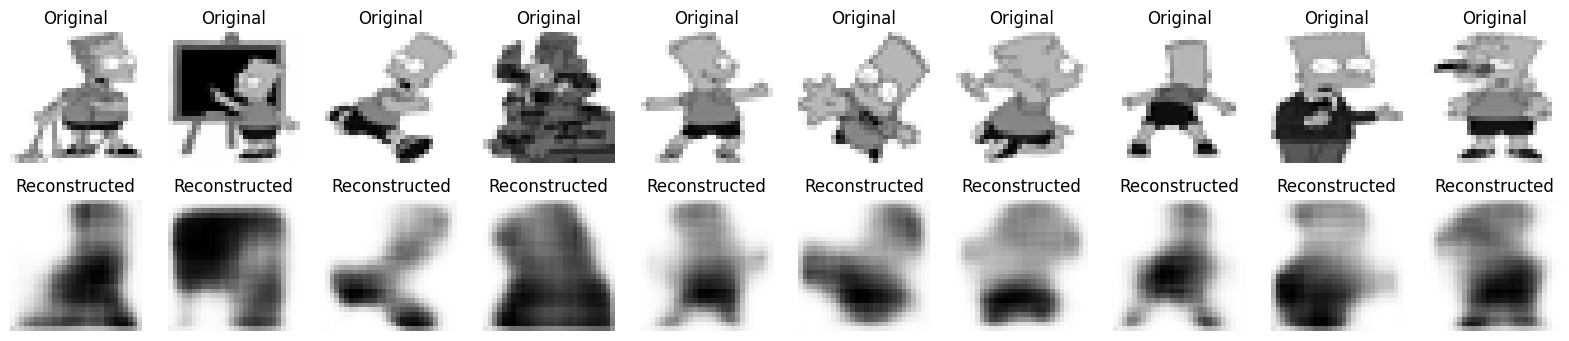

In [ ]:
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(X)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


In [ ]:
noise_factor = 0.4
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)
X_noisy = np.clip(X_noisy, 0., 1.)


In [ ]:
autoencoder.fit(X_noisy, X, epochs=100,batch_size=128, shuffle=True, validation_split=0.2 )


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.5665 - val_loss: 0.5019
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.4722 - val_loss: 0.4477
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4458 - val_loss: 0.4327
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4394 - val_loss: 0.4364
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.4370 - val_loss: 0.4380
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.4378 - val_loss: 0.4292
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.4351 - val_loss: 0.4241
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.4273 - val_loss: 0.4234
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4247 - val_loss: 0.4139
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.4179 - val_loss: 0.4114
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.4160 - val_loss: 0.4080
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4145 - val_l

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


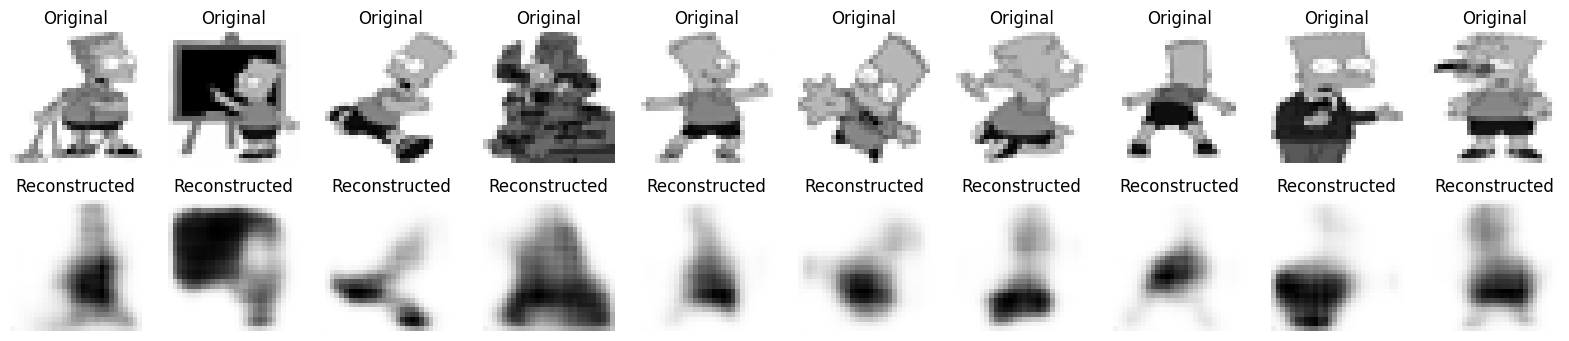

In [ ]:
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(X)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from sklearn.model_selection import train_test_split


In [ ]:
# Load dataset
df = pd.read_csv('homer_bart_dataset.csv')

# Normalize and reshape
X = df.drop('label', axis=1).astype('float32') / 255.0
X = X.values.reshape(-1, 28, 28, 1)

# Split data
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)


In [ ]:
noise_factor = 0.4
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Clip values to be between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)


In [ ]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Compile model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,425 (185.25 KB)

 Trainable params: 47,425 (185.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.fit(
    X_train_noisy, X_train,
    epochs=100,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 0.6820 - val_loss: 0.6306
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.6169 - val_loss: 0.5731
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.5679 - val_loss: 0.5985
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.5783 - val_loss: 0.5617
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.5467 - val_loss: 0.5545
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5455 - val_loss: 0.5467
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.5359 - val_loss: 0.5359
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.5240 - val_loss: 0.5267
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5142 - val_loss: 0.5100
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4982 - val_loss: 0.4970
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.4842 - val_loss: 0.4853
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.4728 - val_los

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step


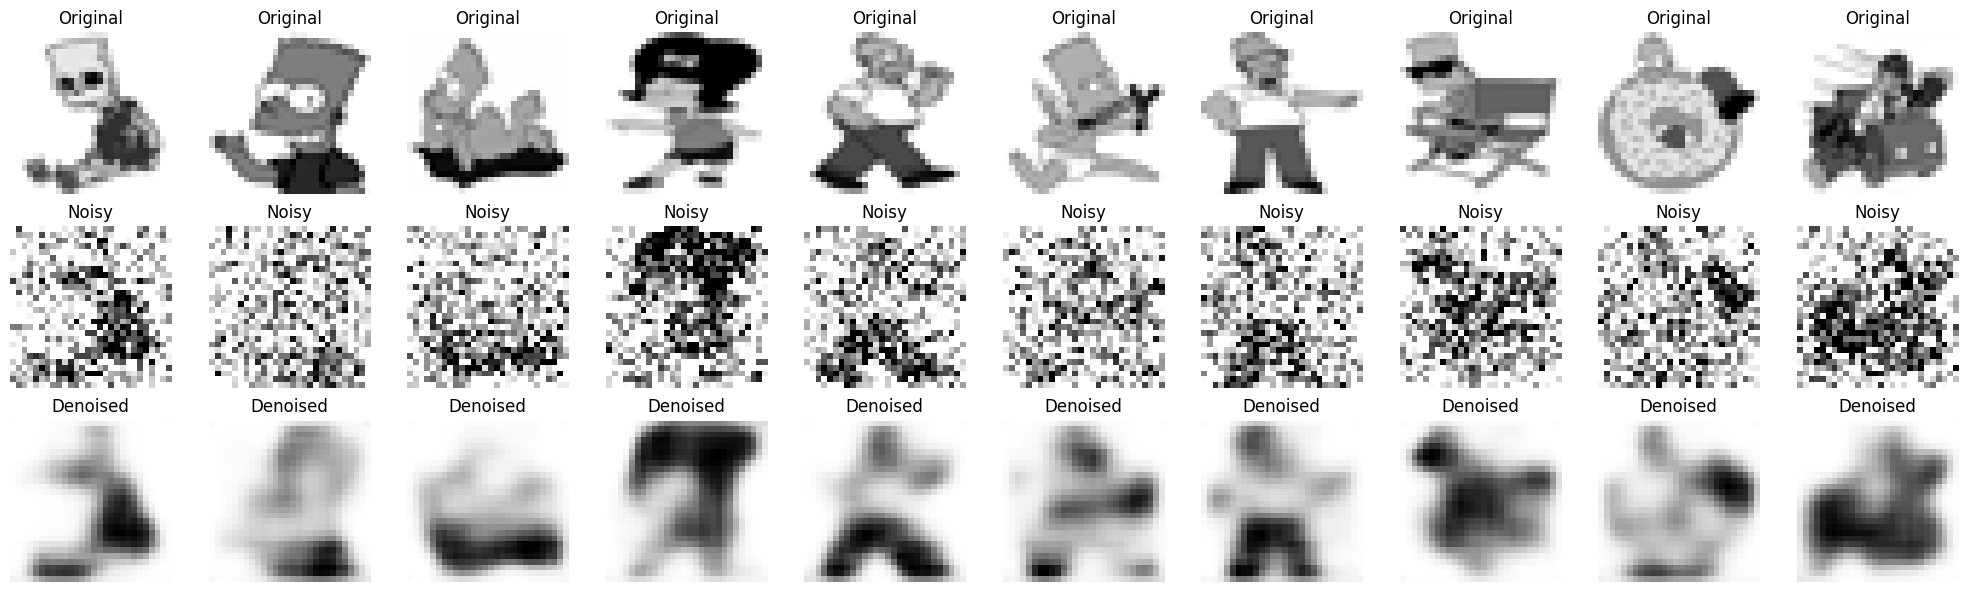

In [ ]:
decoded_imgs = autoencoder.predict(X_test_noisy)

n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()


NOW WE ARE CREATING CNN MODEL ON BOMER VS HOMER IT WILL RECOGNIZE IT IS IMAGE OF WHAT HOMER OR BOMER

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:
# Load CSV file
df = pd.read_csv('homer_bart_dataset.csv')

# Separate features and labels
X = df.drop('label', axis=1).astype('float32') / 255.0
y = df['label']

# Reshape X
X = X.values.reshape(-1, 28, 28, 1)

# Encode labels (bart = 0, homer = 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)  # One-hot encoding

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))  # 2 classes: Homer and Bart


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 489ms/step - accuracy: 0.5970 - loss: 0.7152 - val_accuracy: 0.5741 - val_loss: 0.6815
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5429 - loss: 0.6811 - val_accuracy: 0.5741 - val_loss: 0.6814
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6225 - loss: 0.6688 - val_accuracy: 0.5741 - val_loss: 0.6761
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6169 - loss: 0.6574 - val_accuracy: 0.5741 - val_loss: 0.6696
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6036 - loss: 0.6592 - val_accuracy: 0.5741 - val_loss: 0.6622
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5915 - loss: 0.6425 - val_accuracy: 0.5741 - val_loss: 0.6521
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6356 - loss: 0.6052 - val_accuracy: 0.6111 - val_loss: 0.6346
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6706 - loss: 0.5718 - val_accuracy: 0.5926 - val_loss

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6073 - loss: 2.0134
Test Accuracy: 0.6296


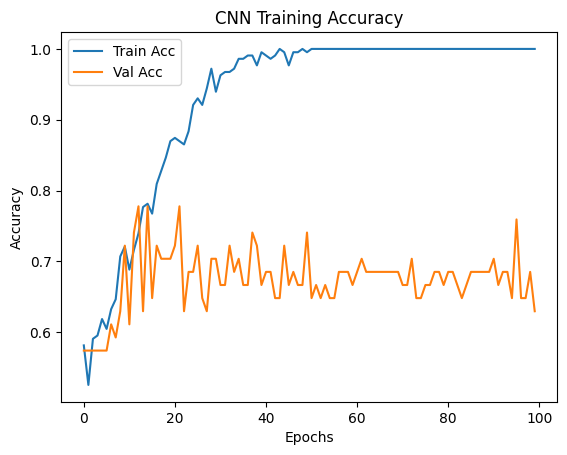

In [ ]:
# Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Training Accuracy')
plt.legend()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


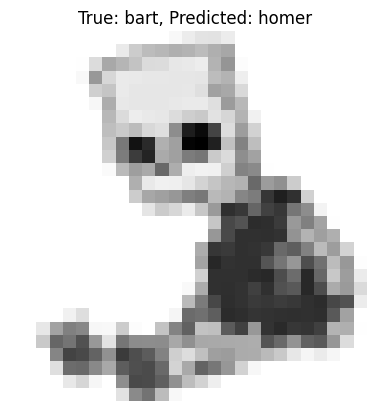

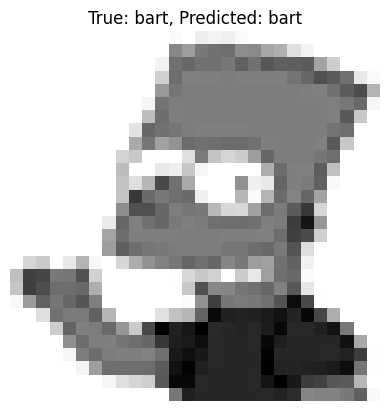

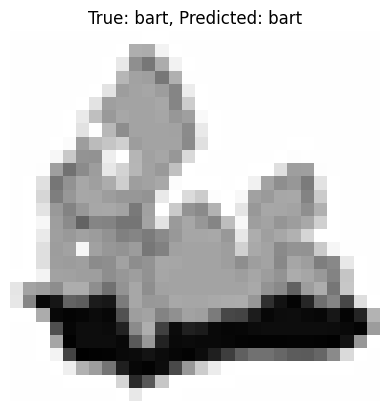

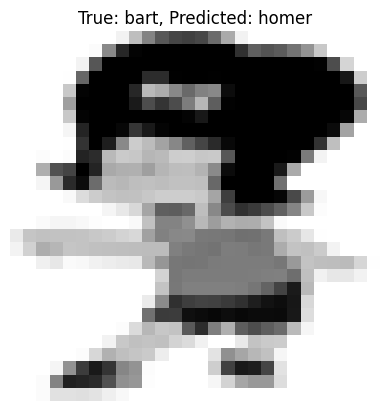

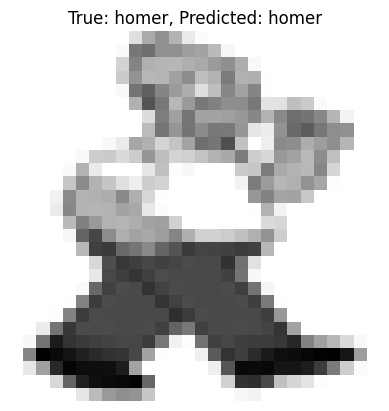

In [ ]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Show some predictions
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {label_encoder.inverse_transform([true_labels[i]])[0]}, Predicted: {label_encoder.inverse_transform([predicted_labels[i]])[0]}")
    plt.axis('off')
    plt.show()


In [ ]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test accuracy
print(f"Test Accuracy: {test_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6073 - loss: 2.0134
Test Accuracy: 0.6296


In [ ]:
df['label'].value_counts()


,count
label,
bart,160
homer,109
